[1/4] 开始读取原始数据...
[1/4] 原始数据读取完成：5,686,993 行，耗时 5.0s。
[1/4] 数据准备完成：19 个信号日，93,432 条完整标签。
[2/4] 开始计算 BP 因子...
[BP 因子] 19/19 个截面 | 100.0% | 当前：2026-06-24 | 已耗时：1.9s | 预计剩余：0.0s
[2/4] BP 因子计算完成：99,236 条记录。
[3/4] 开始计算 IC、RankIC 和因子收益...
[基础指标] 18/18 个截面 | 100.0% | 当前：2026-03-25 | 已耗时：1.8s | 预计剩余：0.0s
[3/4] 基础指标计算完成：18 个有效调仓截面。


,factor_column,ic_mean,icir,rank_ic_mean,rank_icir,factor_return_mean,mean_t_value,cross_section_count,valid_ic_count
0,book_to_price,0.038468,0.555838,0.087299,1.053441,0.00566,2.751592,18,18


,signal_date,return_end_date,sample_count,ic,rank_ic,factor_return,factor_t_value
13,2025-03-27,2025-06-26,5376,-0.009958,0.053226,-0.002107,-0.730051
14,2025-06-26,2025-09-18,5394,-0.028121,0.008660,-0.008946,-2.065759
15,2025-09-18,2025-12-19,5405,0.064207,0.158904,0.013940,4.729313
16,2025-12-19,2026-03-25,5435,0.008211,0.075029,0.002066,0.605250
17,2026-03-25,2026-06-24,5462,-0.087578,-0.047961,-0.038384,-6.496295


[4/4] 开始绘制 IC 与 RankIC 时序图...
[IC 时序图] 4/4 绘制图形.....

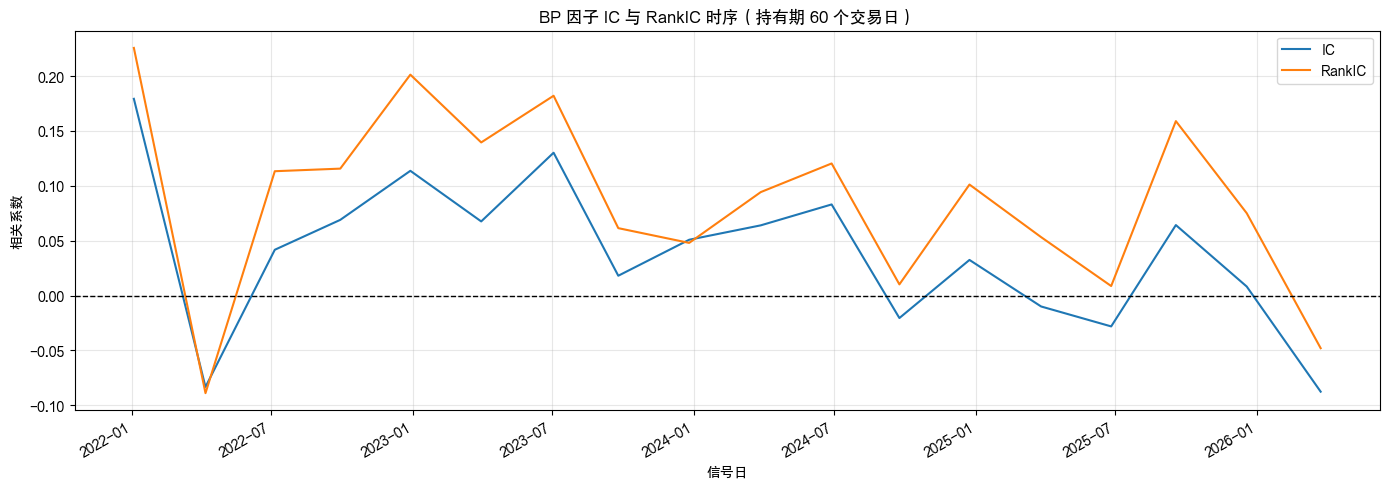

[IC 时序图] 已完成 | 耗时：0.2s
[4/4] 全部完成。


In [1]:
import sys
import time

sys.dont_write_bytecode = True  # 不生成 __pycache__

import pandas as pd
import dai

from factor_lib.factor_hub.get_factor import get_factor
from factor_lib.common.factor_evaluation.calculate_factor_basic_metrics import (
    calculate_factor_basic_metrics,
)
from factor_lib.common.factor_evaluation.plot_ic_rankic_series import (
    plot_ic_rankic_series,
)

# ===== 研究参数 =====
START_DATE = "2022-01-01"
END_DATE = "2026-06-30"

HOLDING_DAYS = 60
REBALANCE_DAYS = 60
MIN_OBS = 30

# ===== 进度显示参数 =====
SHOW_PROGRESS = True
PROGRESS_EVERY = 10

# ===== 第 1 步：读取 BP 因子计算所需的原始数据 =====
print("[1/4] 开始读取原始数据...")

query_start_time = time.perf_counter()

sql = f"""
SELECT
    v.date,
    v.instrument,
    v.pb,
    v.total_market_cap,
    b.close,
    p.cs_level1 AS industry
FROM cn_stock_valuation AS v
JOIN cn_stock_bar1d AS b
    ON v.date = b.date
    AND v.instrument = b.instrument
LEFT JOIN cn_stock_prefactors AS p
    ON v.date = p.date
    AND v.instrument = p.instrument
WHERE v.date BETWEEN '{START_DATE}' AND '{END_DATE}'
"""

raw_data = dai.query(sql).df()

query_elapsed = time.perf_counter() - query_start_time

if raw_data.empty:
    raise ValueError("未查询到数据，请检查日期范围和数据表权限。")

print(
    f"[1/4] 原始数据读取完成：{len(raw_data):,} 行"
    f"，耗时 {query_elapsed:.1f}s。"
)

raw_data["date"] = pd.to_datetime(raw_data["date"])
raw_data = raw_data.drop_duplicates(["date", "instrument"]).copy()

for column in ["pb", "total_market_cap", "close"]:
    raw_data[column] = pd.to_numeric(raw_data[column], errors="coerce")

raw_data = raw_data.loc[raw_data["close"] > 0].copy()

# ===== 构造按全市场交易日计算的未来 60 日收益标签 =====
trading_calendar = (
    pd.DataFrame({"date": sorted(raw_data["date"].unique())})
    .reset_index(drop=True)
)

trading_calendar["return_end_date"] = trading_calendar["date"].shift(
    -HOLDING_DAYS
)

data_with_end_date = raw_data.merge(
    trading_calendar,
    on="date",
    how="left",
)

end_close = raw_data[["date", "instrument", "close"]].rename(
    columns={
        "date": "return_end_date",
        "close": "end_close",
    }
)

label_data = data_with_end_date.merge(
    end_close,
    on=["return_end_date", "instrument"],
    how="left",
)

label_data["forward_return"] = (
    label_data["end_close"] / label_data["close"] - 1
)

# 每 60 个交易日取一次因子值，避免相邻持有期重叠。
signal_dates = set(
    trading_calendar.iloc[::REBALANCE_DAYS]["date"]
)

factor_input = data_with_end_date.loc[
    data_with_end_date["date"].isin(signal_dates),
    ["date", "instrument", "pb", "total_market_cap", "industry"],
].copy()

label_data = label_data.loc[
    label_data["date"].isin(signal_dates),
    ["date", "instrument", "forward_return", "return_end_date"],
].copy()

# 只保留未来 60 日收益已完整结束的样本。
label_data = label_data.dropna(
    subset=["forward_return", "return_end_date"]
).copy()

print(
    f"[1/4] 数据准备完成："
    f"{len(signal_dates)} 个信号日，"
    f"{len(label_data):,} 条完整标签。"
)

# ===== 第 2 步：通过因子中心计算 BP =====
print("[2/4] 开始计算 BP 因子...")

bp_factor = get_factor(
    "book_to_price",
    factor_input,
    neutralize_industry=True,
    winsor_k=5.0,
    min_cs_count=MIN_OBS,
    show_progress=SHOW_PROGRESS,
    progress_every=PROGRESS_EVERY,
)

print(f"[2/4] BP 因子计算完成：{len(bp_factor):,} 条记录。")

# ===== 第 3 步：计算 BP 基础评价指标 =====
print("[3/4] 开始计算 IC、RankIC 和因子收益...")

bp_metrics = calculate_factor_basic_metrics(
    factor_data=bp_factor,
    label_data=label_data,
    factor_column="book_to_price",
    return_column="forward_return",
    date_column="date",
    instrument_column="instrument",
    return_end_date_column="return_end_date",
    min_obs=MIN_OBS,
    show_progress=SHOW_PROGRESS,
    progress_every=PROGRESS_EVERY,
)

print(
    f"[3/4] 基础指标计算完成："
    f"{len(bp_metrics['timeseries']):,} 个有效调仓截面。"
)

display(bp_metrics["summary"])
display(bp_metrics["timeseries"].tail())

# ===== 第 4 步：绘制 IC 与 RankIC 时序图 =====
print("[4/4] 开始绘制 IC 与 RankIC 时序图...")

fig, ax = plot_ic_rankic_series(
    metrics_timeseries=bp_metrics["timeseries"],
    date_column="signal_date",
    ic_column="ic",
    rank_ic_column="rank_ic",
    title=(
        f"BP 因子 IC 与 RankIC 时序"
        f"（持有期 {HOLDING_DAYS} 个交易日）"
    ),
    figsize=(14, 5),
    show=True,
    show_progress=SHOW_PROGRESS,
)

print("[4/4] 全部完成。")

In [ ]:
import sys
sys.dont_write_bytecode = True

import pandas as pd
import dai

from factor_lib.factor_hub.get_factor import get_factor
from factor_lib.common.strategies.market_cap_group_backtest import (
    run_market_cap_group_backtest,
)

# ===== 参数 =====
START_DATE = "2022-01-01"
END_DATE = "2026-06-30"

REBALANCE_INTERVAL = 20
MARKET_CAP_GROUP_COUNT = 15
SELECTED_MARKET_CAP_GROUPS = list(range(1, 16))

# ===== 确定因子计算与调仓信号日 =====
calendar = dai.query(
    f"""
    SELECT DISTINCT date
    FROM cn_stock_bar1d
    WHERE date BETWEEN '{START_DATE}' AND '{END_DATE}'
    ORDER BY date
    """
).df()

calendar["date"] = pd.to_datetime(calendar["date"])

if len(calendar) < 2:
    raise ValueError("回测区间交易日不足。")

# 与市值分组函数相同：
# 从首个真实交易日开始，每 20 个交易日调仓；
# 最后一个交易日没有下一交易日开盘，不能作为信号日。
signal_dates = calendar["date"].iloc[
    :-1:REBALANCE_INTERVAL
].tolist()

signal_dates_sql = ", ".join(
    f"'{date:%Y-%m-%d}'"
    for date in signal_dates
)

# ===== 读取并计算 BP =====
factor_input = dai.query(
    f"""
    SELECT
        v.date,
        v.instrument,
        v.pb,
        v.total_market_cap,
        p.cs_level1 AS industry
    FROM cn_stock_valuation AS v
    LEFT JOIN cn_stock_prefactors AS p
        ON v.date = p.date
        AND v.instrument = p.instrument
    WHERE v.date IN ({signal_dates_sql})
    """
).df()

if factor_input.empty:
    raise ValueError("未读取到 BP 因子数据。")

factor_input["date"] = pd.to_datetime(factor_input["date"])
factor_input = factor_input.drop_duplicates(
    ["date", "instrument"]
).copy()

for column in ["pb", "total_market_cap"]:
    factor_input[column] = pd.to_numeric(
        factor_input[column],
        errors="coerce",
    )

bp_factor = get_factor(
    "book_to_price",
    data=factor_input,
    target_dates=signal_dates,
    neutralize_industry=True,
    winsor_k=5.0,
    min_cs_count=30,
    show_progress=True,
    progress_every=10,
)

# ===== BP 市值分组回测 =====
# factor_name 用于从因子中心自动读取 FACTOR["direction"]。
# 因此这里不再传 factor_direction。
result = run_market_cap_group_backtest(
    factor_data=bp_factor,
    factor_column="book_to_price",
    factor_name="book_to_price",
    universe="all_a",
    start_date=START_DATE,
    end_date=END_DATE,
    market_cap_group_count=MARKET_CAP_GROUP_COUNT,
    selected_market_cap_groups=SELECTED_MARKET_CAP_GROUPS,
    rebalance_interval=REBALANCE_INTERVAL,
    initial_cash=1_000_000,
    benchmark="000300.SH",
    trading_costs={
        "buy_cost": 0.0003,
        "sell_cost": 0.0003,
        "min_cost": 5.0,
        "tax_ratio": 0.0005,
    },
    volume_limit=0.025,
    show_progress=True,
    progress_every=10,
)

# ===== 查看结果 =====
print(f"识别到的因子名称：{result['factor_name']}")
print(f"自动读取的因子方向：{result['factor_direction']}")
print(f"自动使用的选股分位区间：{result['factor_quantile_range']}")

display(result["backtest"])
display(result["rebalance_audit"].tail(20))
display(result["trade_audit"].tail(20))

print(f"BP 因子记录数：{len(bp_factor):,}")
print(f"理论目标权重记录数：{len(result['target_weights']):,}")
print(f"实际成交记录数：{len(result['trade_audit']):,}")